<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Preset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/preset 350 microns study.xlsx')

In [ ]:
sheets = pd.ExcelFile('/content/drive/MyDrive/preset 350 microns study.xlsx')

In [ ]:
sheets.sheet_names

['PRE OP PARAMETERS', 'POST OP PARAMETERS-DAY 1', 'operating eyes AK']

In [ ]:
# prompt: Open operating eyes AK

import pandas as pd
operating_eyes_AK = pd.read_excel(sheets, 'operating eyes AK')

operating_eyes_AK

,preop-R1,preop-R2,preop-A1,Postop-R1,Postop-R2,Postop-A1
0,43.50,43.75,35,43.25,43.250,180
1,43.00,44.00,75,43.25,43.750,135
2,44.50,46.00,95,45.25,48.500,180
3,43.25,44.50,60,43.00,44.750,60
4,42.25,43.75,100,43.00,43.250,120
5,43.00,44.50,80,42.25,45.000,85
6,46.00,46.75,105,43.75,50.509,160
7,44.25,46.50,55,46.75,48.250,170
8,44.50,45.25,25,40.25,44.250,165
9,44.50,45.00,130,44.75,45.000,135


In [ ]:
# prompt: Descriptive statistics

operating_eyes_AK.describe()

,preop-R1,preop-R2,preop-A1,Postop-R1,Postop-R2,Postop-A1
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,44.069444,44.951389,80.555556,43.722222,45.847472,104.166667
std,1.561377,1.598905,37.335884,2.025531,2.490660,58.229840
min,40.250000,40.750000,5.000000,37.750000,38.500000,10.000000
25%,42.937500,44.000000,60.000000,42.437500,44.250000,60.000000
50%,44.125000,44.750000,85.000000,43.750000,45.875000,100.000000
75%,45.250000,46.312500,106.250000,45.312500,47.375000,166.250000
max,47.000000,47.500000,150.000000,47.000000,50.750000,180.000000


In [ ]:
# prompt: Correlation

operating_eyes_AK.corr(numeric_only=True)

,preop-R1,preop-R2,preop-A1,Postop-R1,Postop-R2,Postop-A1
preop-R1,1.000000,0.936274,-0.109731,0.759492,0.589775,0.102394
preop-R2,0.936274,1.000000,-0.138332,0.826088,0.629110,0.022568
preop-A1,-0.109731,-0.138332,1.000000,-0.041821,0.030195,0.082685
Postop-R1,0.759492,0.826088,-0.041821,1.000000,0.668835,-0.003230
Postop-R2,0.589775,0.629110,0.030195,0.668835,1.000000,0.189796
Postop-A1,0.102394,0.022568,0.082685,-0.003230,0.189796,1.000000


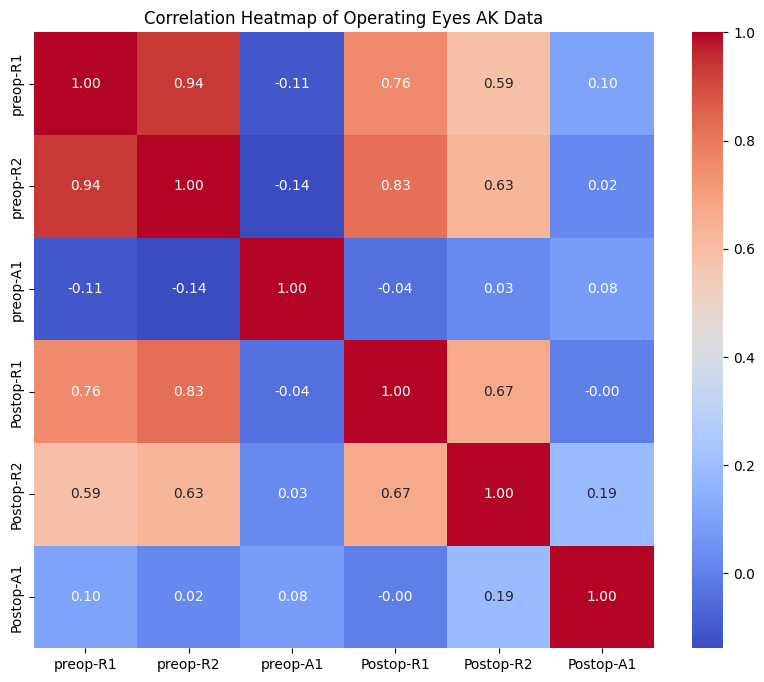

In [ ]:
# prompt: Hetmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(operating_eyes_AK.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Operating Eyes AK Data')
plt.show()


In [ ]:
operating_eyes_AK.columns

Index(['preop-R1', 'preop-R2', 'preop-A1', 'Postop-R1', 'Postop-R2',
       'Postop-A1'],
      dtype='object')

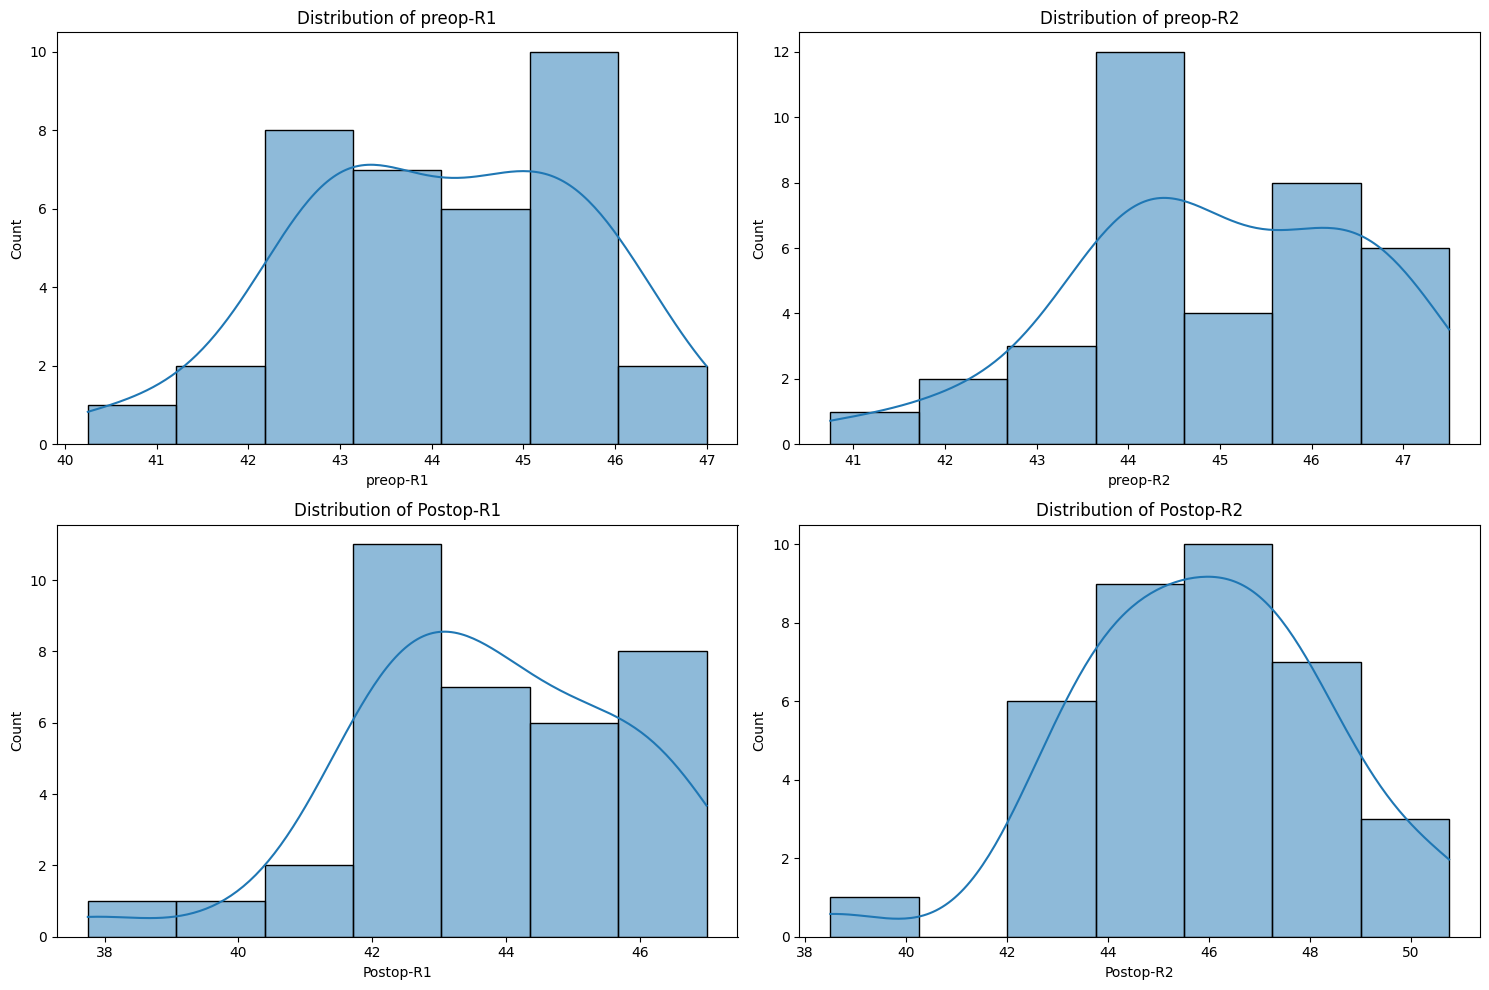

In [ ]:
# prompt: Histograms. preop-R1', 'preop-R2',  'Postop-R1', 'Postop-R2

import matplotlib.pyplot as plt
cols_to_plot = ['preop-R1', 'preop-R2', 'Postop-R1', 'Postop-R2']

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_to_plot):
  plt.subplot(2, 2, i + 1) # Create a 2x2 grid of subplots
  sns.histplot(data=operating_eyes_AK, x=col, kde=True)
  plt.title(f'Distribution of {col}')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

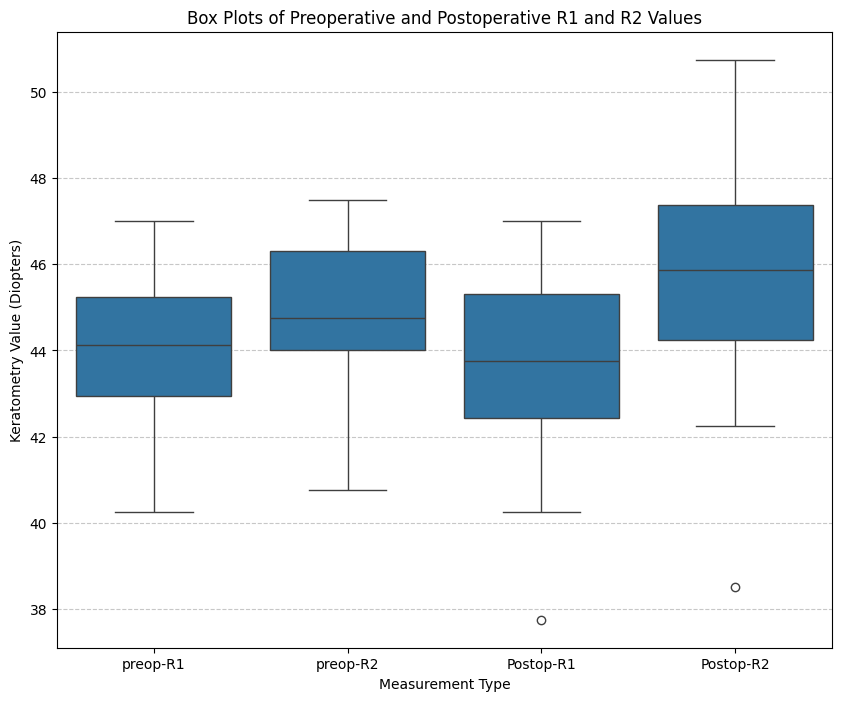

In [ ]:
# prompt: Box plots

import matplotlib.pyplot as plt
# Melt the dataframe for easier plotting with seaborn
df_melted = operating_eyes_AK.melt(value_vars=cols_to_plot, var_name='Measurement Type', value_name='Value')

plt.figure(figsize=(10, 8))
sns.boxplot(data=df_melted, x='Measurement Type', y='Value')
plt.title('Box Plots of Preoperative and Postoperative R1 and R2 Values')
plt.ylabel('Keratometry Value (Diopters)')
plt.xticks(rotation=0) # Keep x-axis labels horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# You can also add individual box plots for each category if you prefer
# For example:
# plt.figure(figsize=(10, 5))
# sns.boxplot(data=operating_eyes_AK, y='preop-R1')
# plt.title('Box Plot of Preoperative R1')
# plt.show()

# plt.figure(figsize=(10, 5))
# sns.boxplot(data=operating_eyes_AK, y='preop-R2')
# plt.title('Box Plot of Preoperative R2')
# plt.show()

# etc.


In [ ]:
# prompt: T test

# T-test for independent samples
from scipy import stats

# Assuming you want to compare 'preop-R1' and 'Postop-R1'
# First, check for normality (optional but good practice)
# For example, using Shapiro-Wilk test
# stat, p = stats.shapiro(operating_eyes_AK['preop-R1'].dropna())
# print(f'Shapiro-Wilk Test for preop-R1: Statistics={stat:.3f}, p={p:.3f}')
# stat, p = stats.shapiro(operating_eyes_AK['Postop-R1'].dropna())
# print(f'Shapiro-Wilk Test for Postop-R1: Statistics={stat:.3f}, p={p:.3f}')

# Assume equal variances (default behavior of scipy.stats.ttest_ind)
# If variances are significantly different (check with Levene's test), set equal_var=False
# stat, p = stats.levene(operating_eyes_AK['preop-R1'].dropna(), operating_eyes_AK['Postop-R1'].dropna())
# print(f'Levene Test for Variance: Statistics={stat:.3f}, p={p:.3f}')

# Perform the independent samples t-test
t_stat, p_value = stats.ttest_ind(operating_eyes_AK['preop-R1'].dropna(), operating_eyes_AK['Postop-R1'].dropna(), equal_var=True)

print(f"Independent Samples T-Test between preop-R1 and Postop-R1:")
print(f"  T-statistic: {t_stat:.4f}")
print(f"  P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
  print("  Result: Reject the null hypothesis - there is a significant difference between the means.")
else:
  print("  Result: Fail to reject the null hypothesis - there is no significant difference between the means.")

# You can repeat this for other pairs, e.g., 'preop-R2' and 'Postop-R2'
t_stat_r2, p_value_r2 = stats.ttest_ind(operating_eyes_AK['preop-R2'].dropna(), operating_eyes_AK['Postop-R2'].dropna(), equal_var=True)

print(f"\nIndependent Samples T-Test between preop-R2 and Postop-R2:")
print(f"  T-statistic: {t_stat_r2:.4f}")
print(f"  P-value: {p_value_r2:.4f}")

# Interpret the results for R2
if p_value_r2 < alpha:
  print("  Result: Reject the null hypothesis - there is a significant difference between the means.")
else:
  print("  Result: Fail to reject the null hypothesis - there is no significant difference between the means.")


Independent Samples T-Test between preop-R1 and Postop-R1:
  T-statistic: 0.8146
  P-value: 0.4181
  Result: Fail to reject the null hypothesis - there is no significant difference between the means.

Independent Samples T-Test between preop-R2 and Postop-R2:
  T-statistic: -1.8166
  P-value: 0.0736
  Result: Fail to reject the null hypothesis - there is no significant difference between the means.


Linear Regression Model (preop-R1 predicting Postop-R1):
  Mean Squared Error (MSE): 1.7290
  R-squared (R2): 0.4404
  Model Intercept: 2.8431
  Model Coefficient (preop-R1): 0.9306


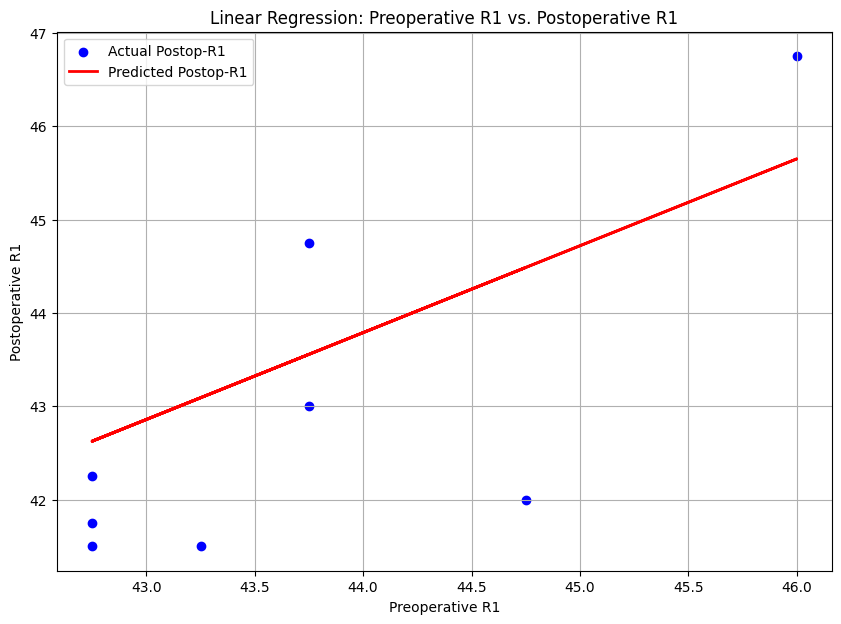


Linear Regression Model (preop-R2 predicting Postop-R2):
  Mean Squared Error (MSE): 3.7226
  R-squared (R2): 0.0562
  Model Intercept: -0.9243
  Model Coefficient (preop-R2): 1.0401


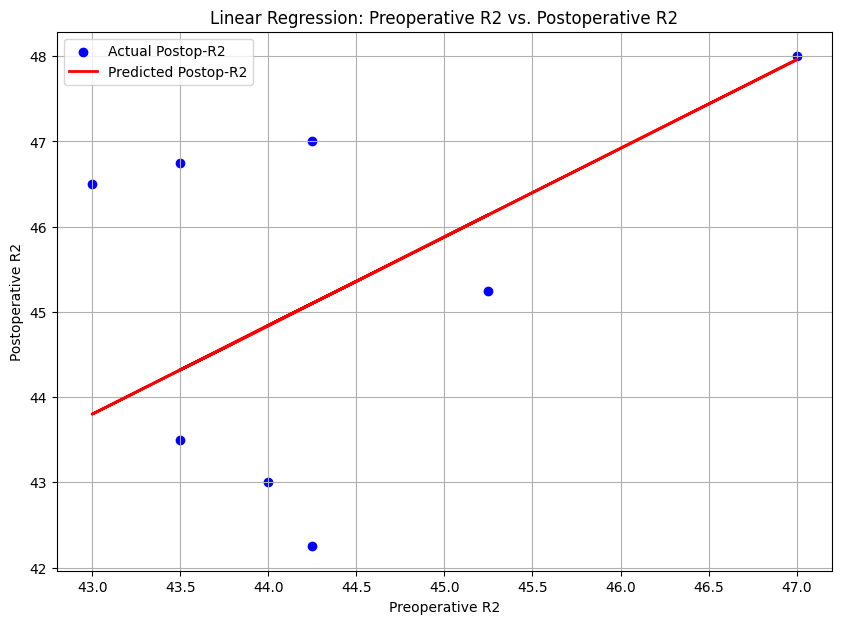

In [ ]:
# prompt: Regression

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Drop rows with NaN values in the relevant columns for regression
regression_df = operating_eyes_AK[['preop-R1', 'Postop-R1']].dropna()

# Define independent variable (X) and dependent variable (y)
X = regression_df[['preop-R1']] # Independent variable (preop-R1) - ensure it's a DataFrame
y = regression_df['Postop-R1'] # Dependent variable (Postop-R1) - ensure it's a Series

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% train, 20% test

# Create a linear regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Model (preop-R1 predicting Postop-R1):")
print(f"  Mean Squared Error (MSE): {mse:.4f}")
print(f"  R-squared (R2): {r2:.4f}")
print(f"  Model Intercept: {model.intercept_:.4f}")
print(f"  Model Coefficient (preop-R1): {model.coef_[0]:.4f}")

# Plotting the regression results
plt.figure(figsize=(10, 7))
plt.scatter(X_test, y_test, color='blue', label='Actual Postop-R1')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Postop-R1')
plt.xlabel('Preoperative R1')
plt.ylabel('Postoperative R1')
plt.title('Linear Regression: Preoperative R1 vs. Postoperative R1')
plt.legend()
plt.grid(True)
plt.show()

# You can repeat this process for other pairs, like 'preop-R2' predicting 'Postop-R2'
regression_df_r2 = operating_eyes_AK[['preop-R2', 'Postop-R2']].dropna()

X_r2 = regression_df_r2[['preop-R2']]
y_r2 = regression_df_r2['Postop-R2']

X_train_r2, X_test_r2, y_train_r2, y_test_r2 = train_test_split(X_r2, y_r2, test_size=0.2, random_state=42)

model_r2 = LinearRegression()
model_r2.fit(X_train_r2, y_train_r2)
y_pred_r2 = model_r2.predict(X_test_r2)

mse_r2 = mean_squared_error(y_test_r2, y_pred_r2)
r2_r2 = r2_score(y_test_r2, y_pred_r2)

print("\nLinear Regression Model (preop-R2 predicting Postop-R2):")
print(f"  Mean Squared Error (MSE): {mse_r2:.4f}")
print(f"  R-squared (R2): {r2_r2:.4f}")
print(f"  Model Intercept: {model_r2.intercept_:.4f}")
print(f"  Model Coefficient (preop-R2): {model_r2.coef_[0]:.4f}")

# Plotting the regression results for R2
plt.figure(figsize=(10, 7))
plt.scatter(X_test_r2, y_test_r2, color='blue', label='Actual Postop-R2')
plt.plot(X_test_r2, y_pred_r2, color='red', linewidth=2, label='Predicted Postop-R2')
plt.xlabel('Preoperative R2')
plt.ylabel('Postoperative R2')
plt.title('Linear Regression: Preoperative R2 vs. Postoperative R2')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# prompt: Ols

import statsmodels.api as sm

# Prepare data for OLS (preop-R1 predicting Postop-R1)
# Add a constant to the independent variable for the intercept
X_ols = sm.add_constant(regression_df[['preop-R1']])
y_ols = regression_df['Postop-R1']

# Create and fit the OLS model
ols_model = sm.OLS(y_ols, X_ols)
ols_results = ols_model.fit()

# Print the summary of the OLS regression results
print("\nOLS Regression Results (preop-R1 predicting Postop-R1):")
print(ols_results.summary())

# Prepare data for OLS (preop-R2 predicting Postop-R2)
X_ols_r2 = sm.add_constant(regression_df_r2[['preop-R2']])
y_ols_r2 = regression_df_r2['Postop-R2']

# Create and fit the OLS model for R2
ols_model_r2 = sm.OLS(y_ols_r2, X_ols_r2)
ols_results_r2 = ols_model_r2.fit()

# Print the summary of the OLS regression results for R2
print("\nOLS Regression Results (preop-R2 predicting Postop-R2):")
print(ols_results_r2.summary())



OLS Regression Results (preop-R1 predicting Postop-R1):
                            OLS Regression Results                            
Dep. Variable:              Postop-R1   R-squared:                       0.577
Model:                            OLS   Adj. R-squared:                  0.564
Method:                 Least Squares   F-statistic:                     46.35
Date:                Sat, 19 Jul 2025   Prob (F-statistic):           7.85e-08
Time:                        02:18:57   Log-Likelihood:                -60.505
No. Observations:                  36   AIC:                             125.0
Df Residuals:                      34   BIC:                             128.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

In [ ]:
# prompt: Equations for models

# Accessing the coefficients for the preop-R1 to Postop-R1 model
intercept_r1 = ols_results.params['const']
coefficient_r1 = ols_results.params['preop-R1']

print(f"\nEquation for predicting Postop-R1: Postop-R1 = {intercept_r1:.4f} + {coefficient_r1:.4f} * preop-R1")

# Accessing the coefficients for the preop-R2 to Postop-R2 model
intercept_r2 = ols_results_r2.params['const']
coefficient_r2 = ols_results_r2.params['preop-R2']

print(f"Equation for predicting Postop-R2: Postop-R2 = {intercept_r2:.4f} + {coefficient_r2:.4f} * preop-R2")



Equation for predicting Postop-R1: Postop-R1 = 0.3020 + 0.9853 * preop-R1
Equation for predicting Postop-R2: Postop-R2 = 1.7959 + 0.9800 * preop-R2


In [ ]:
# prompt: For ols regression equation

# Extract the regression equation strings from the OLS results summaries
equation_r1_str = f"Equation for predicting Postop-R1: Postop-R1 = {intercept_r1:.4f} + {coefficient_r1:.4f} * preop-R1"
equation_r2_str = f"Equation for predicting Postop-R2: Postop-R2 = {intercept_r2:.4f} + {coefficient_r2:.4f} * preop-R2"

print("\nOLS Regression Equations:")
print(equation_r1_str)
equation_r2_str



OLS Regression Equations:
Equation for predicting Postop-R1: Postop-R1 = 0.3020 + 0.9853 * preop-R1


'Equation for predicting Postop-R2: Postop-R2 = 1.7959 + 0.9800 * preop-R2'


Astigmatism Magnitudes:
   preop-R1  preop-R2  Postop-R1  Postop-R2  preop_Astig_Mag  Postop_Astig_Mag
0     43.50     43.75      43.25      43.25             0.25              0.00
1     43.00     44.00      43.25      43.75             1.00              0.50
2     44.50     46.00      45.25      48.50             1.50              3.25
3     43.25     44.50      43.00      44.75             1.25              1.75
4     42.25     43.75      43.00      43.25             1.50              0.25


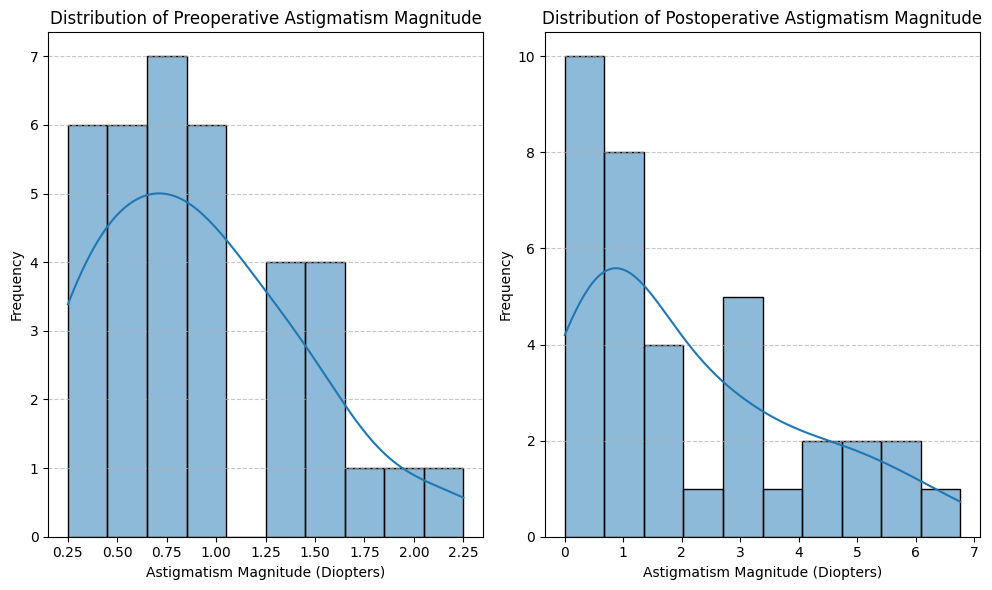


Description of Astigmatism Magnitudes:
       preop_Astig_Mag  Postop_Astig_Mag
count        36.000000         36.000000
mean          0.909722          2.125250
std           0.518076          1.886197
min           0.250000          0.000000
25%           0.500000          0.500000
50%           0.750000          1.375000
75%           1.250000          3.250000
max           2.250000          6.759000


In [ ]:
# prompt: SIA vector Pythagorean

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Calculate astigmatism magnitudes
# Assuming 'preop-R1', 'preop-R2', 'Postop-R1', 'Postop-R2' are the R values.
# Astigmatism magnitude is the absolute difference between R2 and R1.

operating_eyes_AK['preop_Astig_Mag'] = np.abs(operating_eyes_AK['preop-R2'] - operating_eyes_AK['preop-R1'])
operating_eyes_AK['Postop_Astig_Mag'] = np.abs(operating_eyes_AK['Postop-R2'] - operating_eyes_AK['Postop-R1'])


# Print the calculated astigmatism magnitudes
print("\nAstigmatism Magnitudes:")
print(operating_eyes_AK[['preop-R1', 'preop-R2', 'Postop-R1', 'Postop-R2', 'preop_Astig_Mag', 'Postop_Astig_Mag']].head())

# You can then analyze the distribution of these magnitudes.
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1) # Subplot for Preop Astigmatism Magnitude
sns.histplot(data=operating_eyes_AK, x='preop_Astig_Mag', kde=True, bins=10)
plt.title('Distribution of Preoperative Astigmatism Magnitude')
plt.xlabel('Astigmatism Magnitude (Diopters)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2) # Subplot for Postop Astigmatism Magnitude
sns.histplot(data=operating_eyes_AK, x='Postop_Astig_Mag', kde=True, bins=10)
plt.title('Distribution of Postoperative Astigmatism Magnitude')
plt.xlabel('Astigmatism Magnitude (Diopters)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


# Example: Describe the astigmatism magnitudes
print("\nDescription of Astigmatism Magnitudes:")
print(operating_eyes_AK[['preop_Astig_Mag', 'Postop_Astig_Mag']].describe())

In [ ]:
operating_eyes_AK.columns

Index(['preop-R1', 'preop-R2', 'preop-A1', 'Postop-R1', 'Postop-R2',
       'Postop-A1', 'preop_Astig_Mag', 'Postop_Astig_Mag'],
      dtype='object')

In [60]:
m1 = operating_eyes_AK['preop-R2'] - operating_eyes_AK['preop-R1']
m2 = operating_eyes_AK['Postop-R2'] - operating_eyes_AK['Postop-R1']

pre_theta = np.radians(2*operating_eyes_AK['preop-A1'])
post_theta = np.radians(2*operating_eyes_AK['Postop-A1'])

Xpre = m1 * np.cos(pre_theta)
Ypre = m1 * np.sin(pre_theta)
Xpost = m2 * np.cos(post_theta)
Ypost = m2 * np.sin(post_theta)

Xsia = Xpost-Xpre
Ysia = Ypost-Ypre

SIA_magnitude = np.sqrt(Xsia**2 + Ysia**2)
# SIA_axis = (np.degrees(np.arctan2(Ysia, Xsia))/2)/180


In [63]:
SIA_axis = (np.degrees(np.arctan2(Ysia, Xsia)) / 2) % 180


In [64]:
SIA_magnitude.describe(), SIA_axis.describe()

(count    36.000000
 mean      2.262156
 std       1.867388
 min       0.000000
 25%       0.974616
 50%       1.657305
 75%       3.544957
 max       7.050826
 dtype: float64,
 count     36.000000
 mean      73.082028
 std       62.186466
 min        0.000000
 25%        6.124439
 50%       72.887257
 75%      127.850985
 max      178.919076
 dtype: float64)

<Axes: >

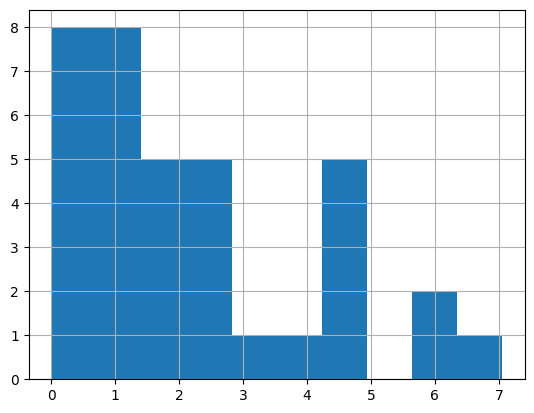

In [65]:
SIA_magnitude.hist()

<Axes: >

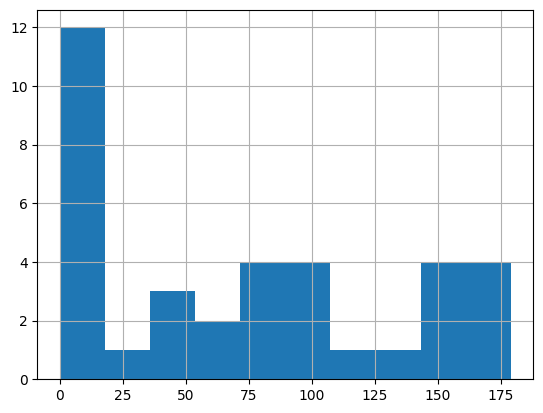

In [66]:
SIA_axis.hist()

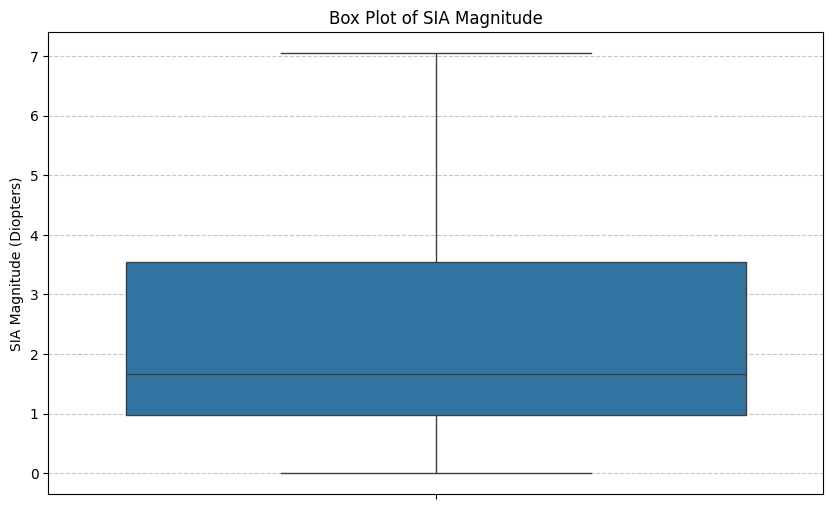

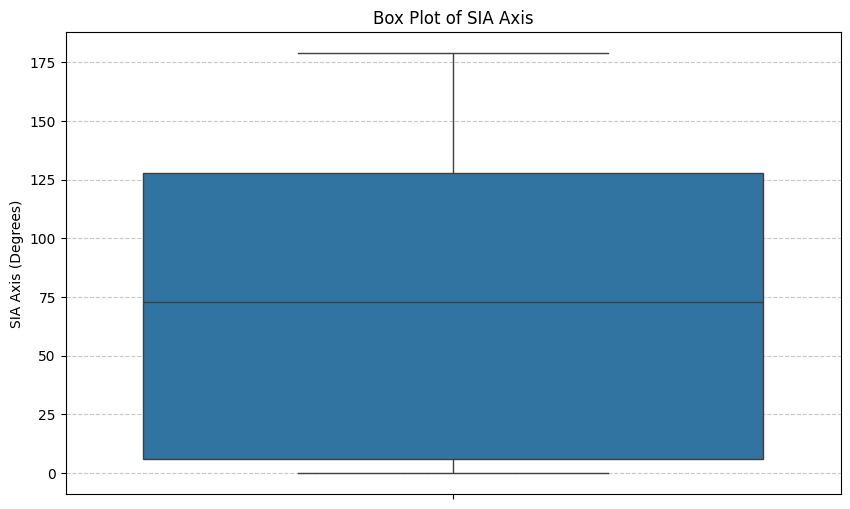

In [67]:
# prompt: Boxplots

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.boxplot(y=SIA_magnitude)
plt.title('Box Plot of SIA Magnitude')
plt.ylabel('SIA Magnitude (Diopters)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(y=SIA_axis)
plt.title('Box Plot of SIA Axis')
plt.ylabel('SIA Axis (Degrees)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

SIA Magnitude for the first patient: 0.2500
SIA Axis for the first patient: 125.0000 degrees


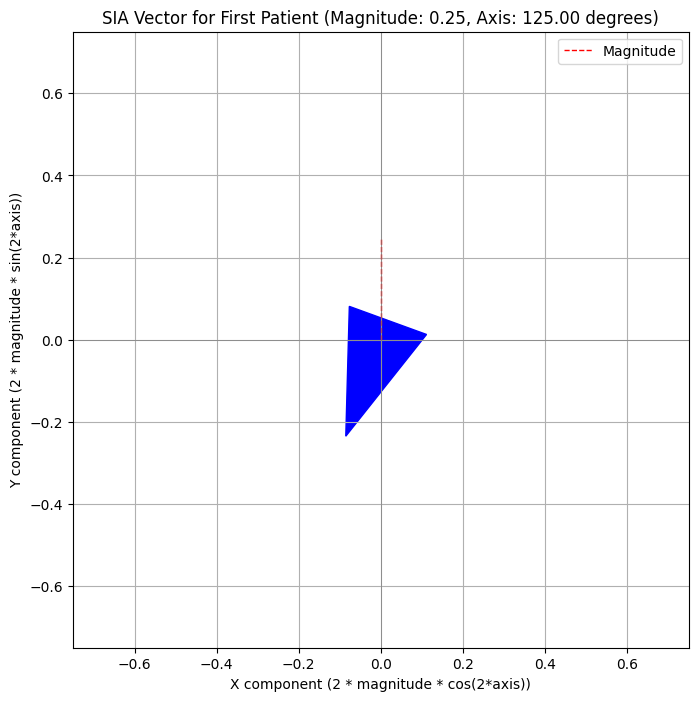

In [68]:
# prompt: Plot sia vector for first patient show magnitude axis

import matplotlib.pyplot as plt
# Extract SIA magnitude and axis for the first patient
sia_magnitude_first = SIA_magnitude.iloc[0]
sia_axis_first = SIA_axis.iloc[0]

print(f"SIA Magnitude for the first patient: {sia_magnitude_first:.4f}")
print(f"SIA Axis for the first patient: {sia_axis_first:.4f} degrees")

# Plotting the SIA vector for the first patient
plt.figure(figsize=(8, 8))

# Plot the vector from the origin (0,0) to the (Xsia, Ysia) point for the first patient
plt.arrow(0, 0, Xsia.iloc[0], Ysia.iloc[0], head_width=0.2, head_length=0.3, fc='blue', ec='blue', length_includes_head=True)

# Plot the magnitude of the vector on the y-axis
plt.plot([0, 0], [0, sia_magnitude_first], color='red', linestyle='--', linewidth=1, label='Magnitude')

# Set limits and labels
max_val = max(abs(Xsia.iloc[0]), abs(Ysia.iloc[0]), sia_magnitude_first) + 0.5
plt.xlim(-max_val, max_val)
plt.ylim(-max_val, max_val)
plt.xlabel('X component (2 * magnitude * cos(2*axis))')
plt.ylabel('Y component (2 * magnitude * sin(2*axis))')
plt.title(f'SIA Vector for First Patient (Magnitude: {sia_magnitude_first:.2f}, Axis: {sia_axis_first:.2f} degrees)')
plt.grid(True)
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure equal aspect ratio
plt.legend()
plt.show()


Centroid of SIA Vector Components:
  Mean Xsia: 0.7163
  Mean Ysia: -0.0349

Centroid of SIA Vector (Mean Vector):
  Centroid Magnitude: 0.7172
  Centroid 2*Axis: -2.7897 degrees
  Centroid Axis: 178.6051 degrees


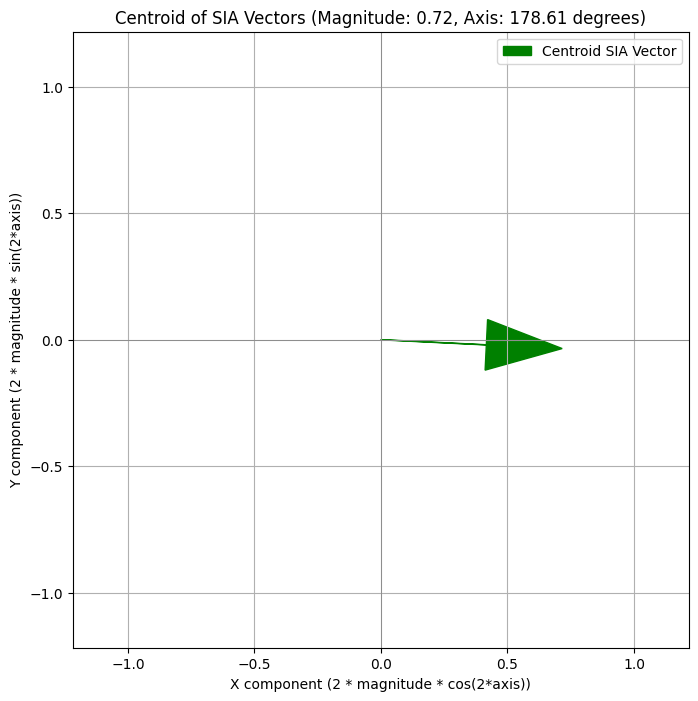

In [69]:
# prompt: Centroid

import matplotlib.pyplot as plt
import numpy as np
# Calculate the mean vector components
mean_Xsia = Xsia.mean()
mean_Ysia = Ysia.mean()

# Calculate the centroid (mean vector) magnitude and axis
centroid_magnitude = np.sqrt(mean_Xsia**2 + mean_Ysia**2)
centroid_axis_radians = np.arctan2(mean_Ysia, mean_Xsia)
# Convert axis to degrees and ensure it's within a standard range (0 to 180 or -90 to 90)
# The axis of astigmatism is generally represented between 0 and 180 degrees.
# Since we are using 2*axis, the range of 2*axis is 0 to 360 or -180 to 180.
# arctan2 gives values between -pi and pi (-180 and 180 degrees for 2*axis).
# We divide by 2 to get the actual axis, which will be between -90 and 90.
# We can adjust this to the 0-180 range if preferred, but for vector plotting, -90 to 90 is often suitable for the 2*axis representation.
# Let's calculate both the 2*axis and the axis.
centroid_2axis_degrees = np.degrees(centroid_axis_radians)
centroid_axis_degrees = centroid_2axis_degrees / 2

# Adjust axis to be between 0 and 180 if needed (optional, depends on desired representation)
# If centroid_axis_degrees is negative, add 180 to bring it into the 0-180 range.
if centroid_axis_degrees < 0:
  centroid_axis_degrees += 180
# If centroid_axis_degrees is >= 180 (unlikely with arctan2/2 but as a safeguard)
if centroid_axis_degrees >= 180:
  centroid_axis_degrees -= 180


print(f"\nCentroid of SIA Vector Components:")
print(f"  Mean Xsia: {mean_Xsia:.4f}")
print(f"  Mean Ysia: {mean_Ysia:.4f}")

print(f"\nCentroid of SIA Vector (Mean Vector):")
print(f"  Centroid Magnitude: {centroid_magnitude:.4f}")
print(f"  Centroid 2*Axis: {centroid_2axis_degrees:.4f} degrees") # 2*axis in the vector space
print(f"  Centroid Axis: {centroid_axis_degrees:.4f} degrees") # Actual astigmatism axis


# Plotting the centroid SIA vector
plt.figure(figsize=(8, 8))

# Plot the centroid vector from the origin (0,0) to the (mean_Xsia, mean_Ysia) point
plt.arrow(0, 0, mean_Xsia, mean_Ysia, head_width=0.2, head_length=0.3, fc='green', ec='green', length_includes_head=True, label='Centroid SIA Vector')

# Set limits and labels
max_abs_val = max(abs(mean_Xsia), abs(mean_Ysia), centroid_magnitude) + 0.5
plt.xlim(-max_abs_val, max_abs_val)
plt.ylim(-max_abs_val, max_abs_val)
plt.xlabel('X component (2 * magnitude * cos(2*axis))')
plt.ylabel('Y component (2 * magnitude * sin(2*axis))')
plt.title(f'Centroid of SIA Vectors (Magnitude: {centroid_magnitude:.2f}, Axis: {centroid_axis_degrees:.2f} degrees)')
plt.grid(True)
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure equal aspect ratio
plt.legend()
plt.show()

In [ ]:
operating_eyes_AK.head()

,preop-R1,preop-R2,preop-A1,Postop-R1,Postop-R2,Postop-A1,preop_Astig_Mag,Postop_Astig_Mag
0,43.50,43.75,35,43.25,43.25,180,0.25,0.00
1,43.00,44.00,75,43.25,43.75,135,1.00,0.50
2,44.50,46.00,95,45.25,48.50,180,1.50,3.25
3,43.25,44.50,60,43.00,44.75,60,1.25,1.75
4,42.25,43.75,100,43.00,43.25,120,1.50,0.25


SIA Magnitude: 0.25 D
SIA Axis: 125.00°


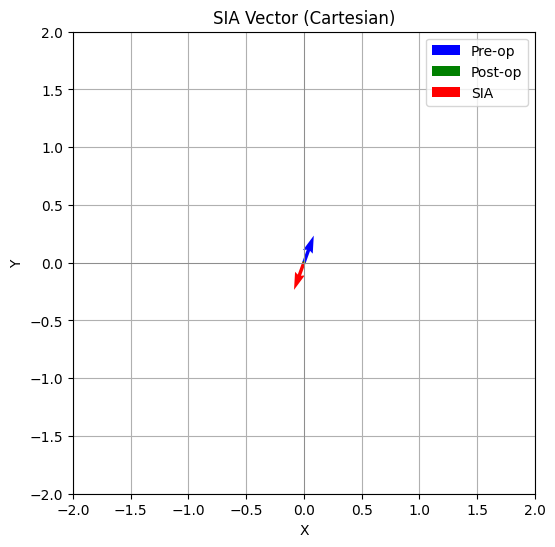

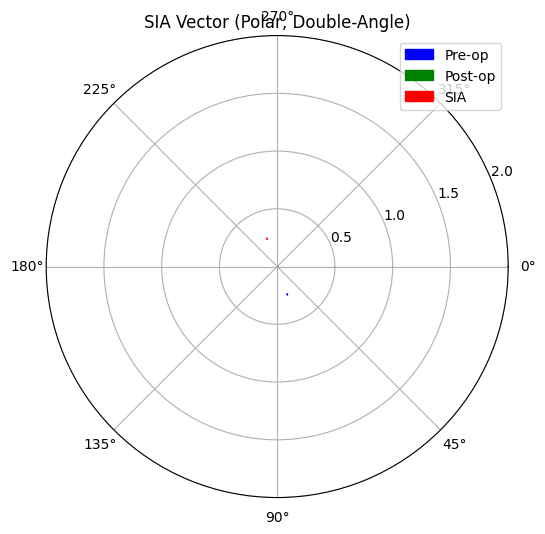

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# === INPUT DATA ===
KH_pre, KV_pre, Axis_pre = 43.50, 43.75, 35    # Pre-op
KH_post, KV_post, Axis_post = 43.25, 43.25, 180  # Post-op

# === STEP 1: Calculate Cylindrical Powers ===
Cyl_pre = KV_pre - KH_pre
Cyl_post = KV_post - KH_post

# === STEP 2: Double Angle Convention (convert axes to radians) ===
theta_pre = np.radians(2 * Axis_pre)
theta_post = np.radians(2 * Axis_post)

# === STEP 3: Convert to Cartesian (X, Y) Coordinates ===
X_pre = Cyl_pre * np.cos(theta_pre)
Y_pre = Cyl_pre * np.sin(theta_pre)

X_post = Cyl_post * np.cos(theta_post)
Y_post = Cyl_post * np.sin(theta_post)

# === STEP 4: Calculate SIA Vector (Post - Pre) ===
X_sia = X_post - X_pre
Y_sia = Y_post - Y_pre

SIA_magnitude = np.sqrt(X_sia**2 + Y_sia**2)
SIA_axis = (np.degrees(np.arctan2(Y_sia, X_sia)) / 2) % 180

print(f"SIA Magnitude: {SIA_magnitude:.2f} D")
print(f"SIA Axis: {SIA_axis:.2f}°")

# === CARTESIAN PLOT ===
plt.figure(figsize=(6,6))
plt.quiver(0, 0, X_pre, Y_pre, angles='xy', scale_units='xy', scale=1, color='blue', label='Pre-op')
plt.quiver(0, 0, X_post, Y_post, angles='xy', scale_units='xy', scale=1, color='green', label='Post-op')
plt.quiver(0, 0, X_sia, Y_sia, angles='xy', scale_units='xy', scale=1, color='red', label='SIA')

plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.gca().set_aspect('equal')
plt.title("SIA Vector (Cartesian)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)

# === POLAR PLOT ===
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_zero_location('E')
ax.set_theta_direction(-1)

# Plotting vectors
ax.arrow(np.radians(2 * Axis_pre), Cyl_pre, 0, 0.01, color='blue', label='Pre-op')
ax.arrow(np.radians(2 * Axis_post), Cyl_post, 0, 0.01, color='green', label='Post-op')
ax.arrow(np.radians(2 * SIA_axis), SIA_magnitude, 0, 0.01, color='red', label='SIA')

# Formatting
ax.set_title("SIA Vector (Polar, Double-Angle)")
ax.set_rticks([0.5, 1.0, 1.5, 2.0])
ax.set_rlabel_position(-22.5)
ax.legend(loc='upper right')

plt.show()


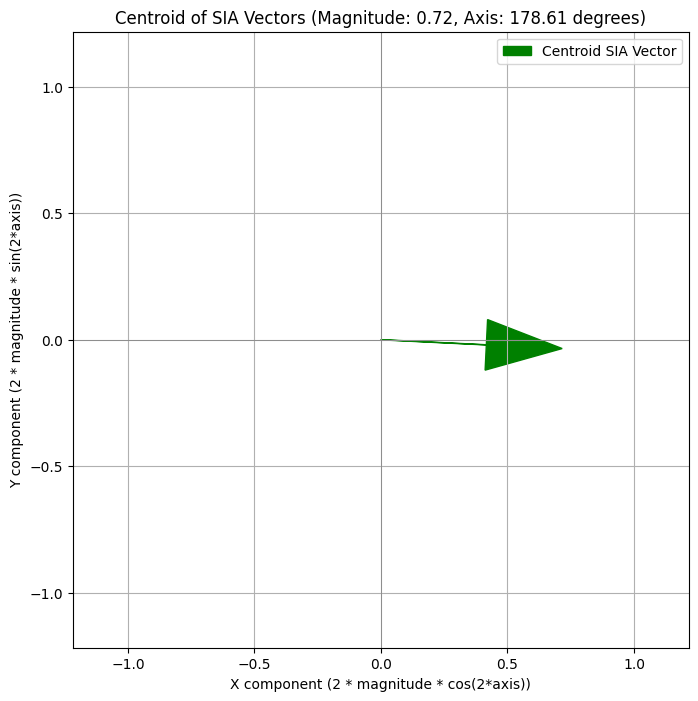

In [70]:
# prompt: Plot centroid

import matplotlib.pyplot as plt
# Plotting the centroid SIA vector
plt.figure(figsize=(8, 8))

# Plot the centroid vector from the origin (0,0) to the (mean_Xsia, mean_Ysia) point
plt.arrow(0, 0, mean_Xsia, mean_Ysia, head_width=0.2, head_length=0.3, fc='green', ec='green', length_includes_head=True, label='Centroid SIA Vector')

# Set limits and labels
max_abs_val = max(abs(mean_Xsia), abs(mean_Ysia), centroid_magnitude) + 0.5
plt.xlim(-max_abs_val, max_abs_val)
plt.ylim(-max_abs_val, max_abs_val)
plt.xlabel('X component (2 * magnitude * cos(2*axis))')
plt.ylabel('Y component (2 * magnitude * sin(2*axis))')
plt.title(f'Centroid of SIA Vectors (Magnitude: {centroid_magnitude:.2f}, Axis: {centroid_axis_degrees:.2f} degrees)')
plt.grid(True)
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.gca().set_aspect('equal', adjustable='box') # Ensure equal aspect ratio
plt.legend()
plt.show()

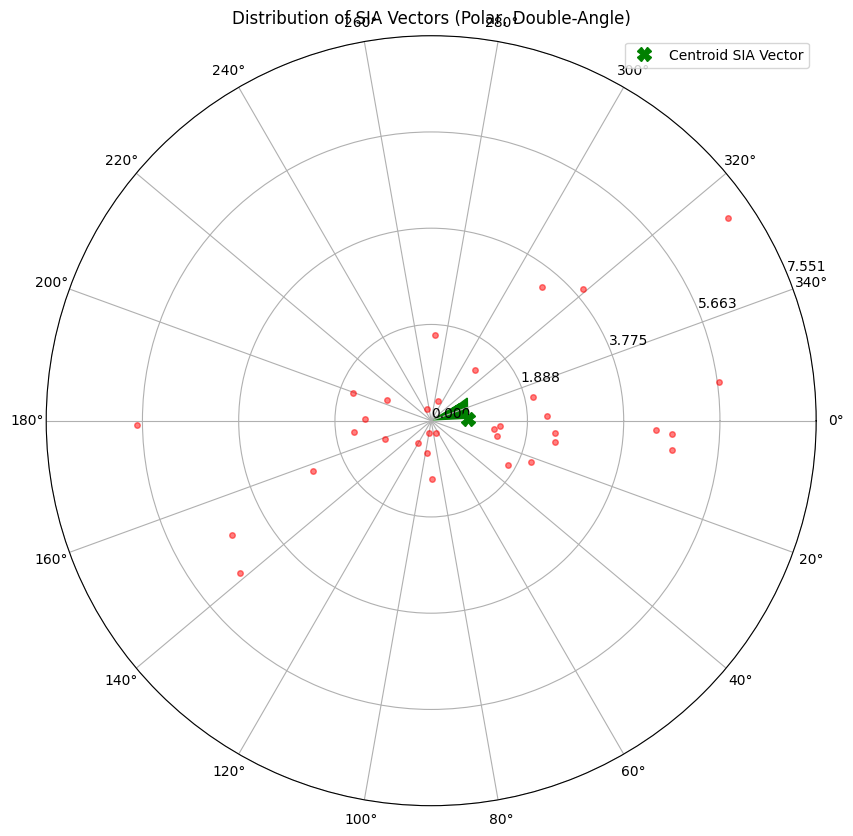

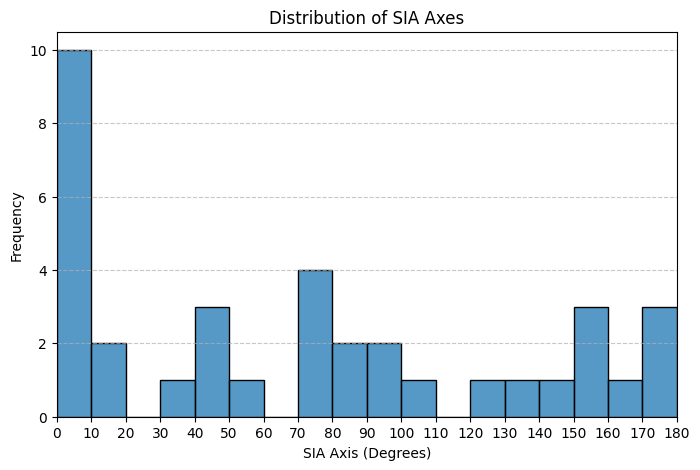

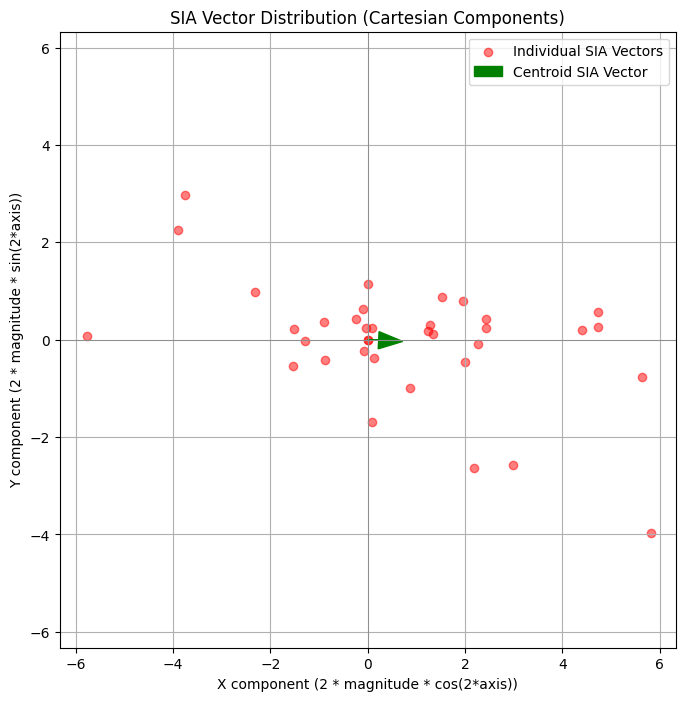

In [71]:
# prompt: Polar plot spacing 10 degrees

import matplotlib.pyplot as plt
import numpy as np
# POLAR PLOT - All SIA Vectors (Double Angle)
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)
ax.set_theta_zero_location('E') # Set 0 degrees to the right (East)
ax.set_theta_direction(-1) # Increase angles clockwise
ax.set_rlabel_position(-22.5) # Adjust radial label position

# Set theta ticks every 10 degrees (in radians for the plot)
ax.set_xticks(np.radians(np.arange(0, 360, 20))) # Set 20 degree spacing for ticks

# Plot each SIA vector
for i in range(len(SIA_magnitude)):
  # Use the 2*axis in radians for the polar plot angle
  angle_rad = np.radians(2 * SIA_axis.iloc[i])
  magnitude = SIA_magnitude.iloc[i]

  # Only plot if magnitude is not NaN and not zero (optional, helps clarity)
  if not np.isnan(magnitude) and magnitude > 0.01: # Avoid plotting tiny vectors at the origin
    # Plot as a point or an arrow; points are often clearer for many vectors
    ax.plot(angle_rad, magnitude, 'o', markersize=4, alpha=0.5, color='red')

# Plot the centroid SIA vector
centroid_angle_rad = np.radians(2 * centroid_axis_degrees)
ax.plot(centroid_angle_rad, centroid_magnitude, 'X', markersize=10, color='green', label='Centroid SIA Vector')
ax.arrow(0, 0, centroid_angle_rad, centroid_magnitude, head_width=np.max(SIA_magnitude)*0.05, head_length=np.max(SIA_magnitude)*0.07, fc='green', ec='green', length_includes_head=True)


# Set radial limits
max_magnitude = np.max(SIA_magnitude)
ax.set_ylim(0, max_magnitude + 0.5) # Add some padding

# Set radial ticks
# You might want to adjust these based on the range of your SIA magnitudes
ax.set_rticks(np.linspace(0, max_magnitude + 0.5, 5)) # Adjust the number of ticks as needed


ax.set_title("Distribution of SIA Vectors (Polar, Double-Angle)", va='bottom')
ax.legend()
plt.grid(True)
plt.show()

# Add a histogram of SIA axes to complement the polar plot
plt.figure(figsize=(8, 5))
sns.histplot(SIA_axis, bins=np.arange(0, 181, 10), kde=False) # Bins every 10 degrees from 0 to 180
plt.title('Distribution of SIA Axes')
plt.xlabel('SIA Axis (Degrees)')
plt.ylabel('Frequency')
plt.xticks(np.arange(0, 181, 10)) # Set x-ticks every 10 degrees
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(0, 180) # Ensure axis range is 0-180
plt.show()

# You could also plot the SIA vector components (Xsia, Ysia) on a standard Cartesian plot
# This is sometimes called a centroid or vector analysis plot.
plt.figure(figsize=(8, 8))
plt.scatter(Xsia, Ysia, alpha=0.5, color='red', label='Individual SIA Vectors')
plt.arrow(0, 0, mean_Xsia, mean_Ysia, head_width=np.max(SIA_magnitude)*0.05, head_length=np.max(SIA_magnitude)*0.07, fc='green', ec='green', length_includes_head=True, label='Centroid SIA Vector')

max_comp_abs = max(abs(Xsia).max(), abs(Ysia).max(), abs(mean_Xsia), abs(mean_Ysia)) + 0.5
plt.xlim(-max_comp_abs, max_comp_abs)
plt.ylim(-max_comp_abs, max_comp_abs)
plt.axhline(0, color='grey', linewidth=0.5)
plt.axvline(0, color='grey', linewidth=0.5)
plt.xlabel('X component (2 * magnitude * cos(2*axis))')
plt.ylabel('Y component (2 * magnitude * sin(2*axis))')
plt.title('SIA Vector Distribution (Cartesian Components)')
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.grid(True)
plt.show()

SIA Magnitude for the first patient: 0.2500
SIA Axis for the first patient: 125.0000 degrees


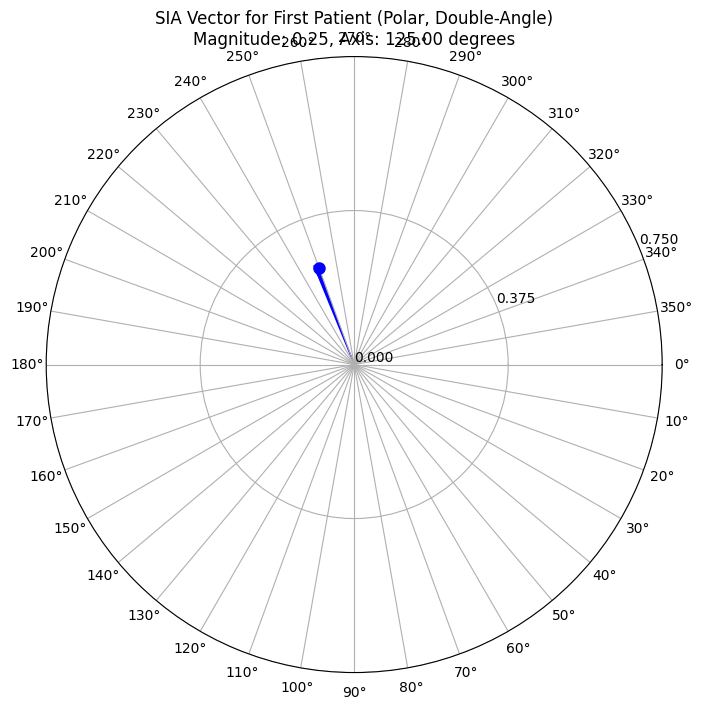

In [74]:
# prompt: SIA vector single patient spacing 10 degrees polar plot

import matplotlib.pyplot as plt
import numpy as np
# Extract SIA magnitude and axis for the first patient
sia_magnitude_first = SIA_magnitude.iloc[0]
sia_axis_first = SIA_axis.iloc[0]

print(f"SIA Magnitude for the first patient: {sia_magnitude_first:.4f}")
print(f"SIA Axis for the first patient: {sia_axis_first:.4f} degrees")

# Plotting the SIA vector for the first patient on a polar plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
ax.set_theta_zero_location('E') # Set 0 degrees to the right (East)
ax.set_theta_direction(-1) # Increase angles clockwise
ax.set_rlabel_position(-22.5) # Adjust radial label position

# Set theta ticks every 10 degrees (in radians for the plot)
# For single patient, you might want finer tick spacing if needed
ax.set_xticks(np.radians(np.arange(0, 360, 10)))

# Convert the actual axis to double angle for polar plot angle (0 to 360)
# Ensure the double angle is between 0 and 360
double_angle_first = (2 * sia_axis_first) % 360
angle_rad_first = np.radians(double_angle_first)

# Plot the vector from the origin
# Use the magnitude for the radial coordinate and double angle for the angular coordinate
ax.arrow(0, 0, angle_rad_first, sia_magnitude_first, head_width=sia_magnitude_first*0.1, head_length=sia_magnitude_first*0.15, fc='blue', ec='blue', length_includes_head=True)

# Add a point at the end of the vector for clarity
ax.plot(angle_rad_first, sia_magnitude_first, 'o', markersize=8, color='blue')


# Set radial limits
max_magnitude_first = sia_magnitude_first
ax.set_ylim(0, max_magnitude_first + 0.5) # Add some padding

# Set radial ticks
# You might want to adjust these based on the magnitude
ax.set_rticks(np.linspace(0, max_magnitude_first + 0.5, 3)) # Adjust the number of ticks as needed


ax.set_title(f'SIA Vector for First Patient (Polar, Double-Angle)\nMagnitude: {sia_magnitude_first:.2f}, Axis: {sia_axis_first:.2f} degrees', va='bottom')

plt.grid(True)
plt.show()

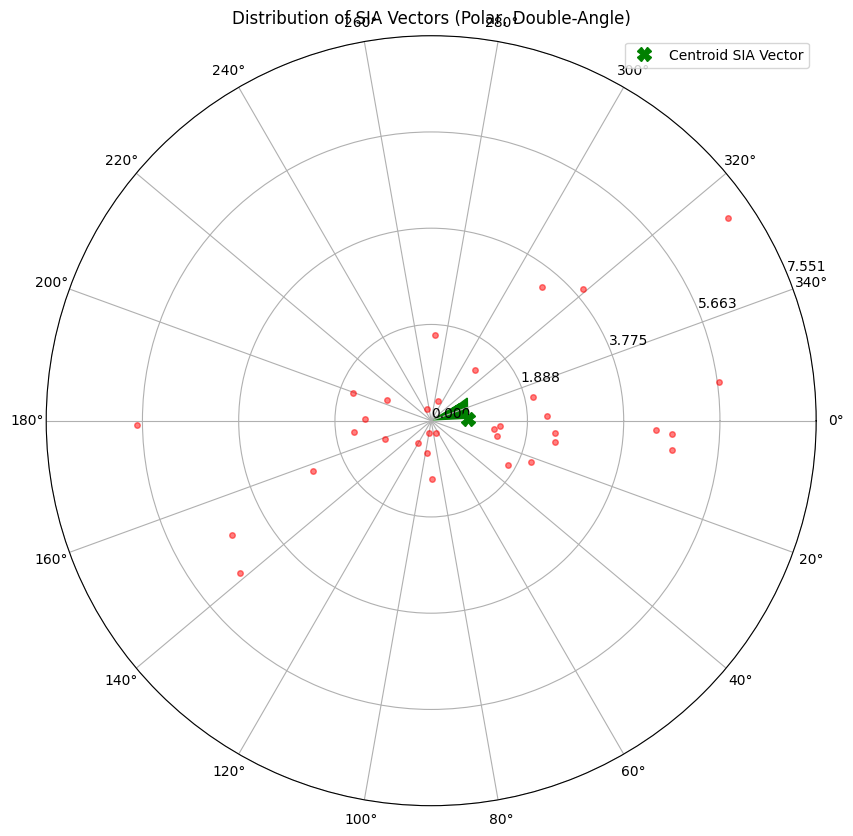

In [73]:
# prompt: Polar plot

import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)
ax.set_theta_zero_location('E') # Set 0 degrees to the right (East)
ax.set_theta_direction(-1) # Increase angles clockwise
ax.set_rlabel_position(-22.5) # Adjust radial label position

# Set theta ticks every 10 degrees (in radians for the plot)
ax.set_xticks(np.radians(np.arange(0, 360, 20))) # Set 20 degree spacing for ticks

# Plot each SIA vector
for i in range(len(SIA_magnitude)):
  # Use the 2*axis in radians for the polar plot angle
  angle_rad = np.radians(2 * SIA_axis.iloc[i])
  magnitude = SIA_magnitude.iloc[i]

  # Only plot if magnitude is not NaN and not zero (optional, helps clarity)
  if not np.isnan(magnitude) and magnitude > 0.01: # Avoid plotting tiny vectors at the origin
    # Plot as a point or an arrow; points are often clearer for many vectors
    ax.plot(angle_rad, magnitude, 'o', markersize=4, alpha=0.5, color='red')

# Plot the centroid SIA vector
centroid_angle_rad = np.radians(2 * centroid_axis_degrees)
ax.plot(centroid_angle_rad, centroid_magnitude, 'X', markersize=10, color='green', label='Centroid SIA Vector')
ax.arrow(0, 0, centroid_angle_rad, centroid_magnitude, head_width=np.max(SIA_magnitude)*0.05, head_length=np.max(SIA_magnitude)*0.07, fc='green', ec='green', length_includes_head=True)


# Set radial limits
max_magnitude = np.max(SIA_magnitude)
ax.set_ylim(0, max_magnitude + 0.5) # Add some padding

# Set radial ticks
# You might want to adjust these based on the range of your SIA magnitudes
ax.set_rticks(np.linspace(0, max_magnitude + 0.5, 5)) # Adjust the number of ticks as needed


ax.set_title("Distribution of SIA Vectors (Polar, Double-Angle)", va='bottom')
ax.legend()
plt.grid(True)
plt.show()

In [ ]:
df.head()

,Name,Date,Age,Gender,Males,Females,RE(Preop diagnosis),LE(Preop diagnosis),RE IOP,LE IOP,...,LE R1,LE R2,LE A1,RE-AL,RE-ACD,RE LT,LE-AL,LE-ACD,LE LT,IOLP
0,Deviramma,19/1/2025,55,F,0,1,PPC,PPC,14,12,...,NaN,NaN,NaN,23.04,3.49,4.02,NaN,NaN,NaN,21.5
1,Sakamma,19/1/2025,69,F,0,1,SMC,PCIOL,9,8,...,NaN,NaN,NaN,21.87,2.82,3.66,NaN,NaN,NaN,25
2,Malamma,19/1/2025,64,F,0,1,PCIOL,SMC,13,12,...,44.5,46.0,95.0,NaN,NaN,NaN,22.41,3.01,3.82,21.5
3,Rajkumar,21/1/2025,57,M,1,0,NC,NC,10,10,...,NaN,NaN,NaN,24.17,3.67,3.72,NaN,NaN,NaN,18.5
4,Chanappa,21/1/25,79,M,1,0,NC,PTHYSIS BULBI,9,14,...,NaN,NaN,NaN,22.84,3.32,3.83,NaN,NaN,NaN,22.5


In [ ]:
df.isnull().sum()

,0
Name,0
Date,0
Age,0
Gender,0
Males,0
Females,0
RE(Preop diagnosis),0
LE(Preop diagnosis),0
RE IOP,0
LE IOP,0


In [ ]:
df_age = df['Age']
df_age.isnull().sum()
df_age.describe()

,Age
count,36.000000
mean,67.527778
std,9.805206
min,39.000000
25%,60.000000
50%,66.000000
75%,76.000000
max,82.000000


<Axes: >

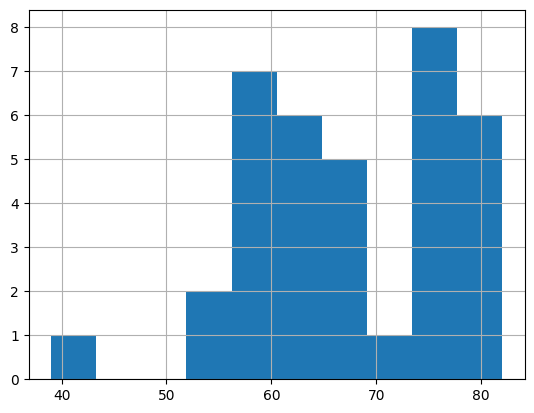

In [ ]:
df_age.hist()

<Axes: ylabel='Age'>

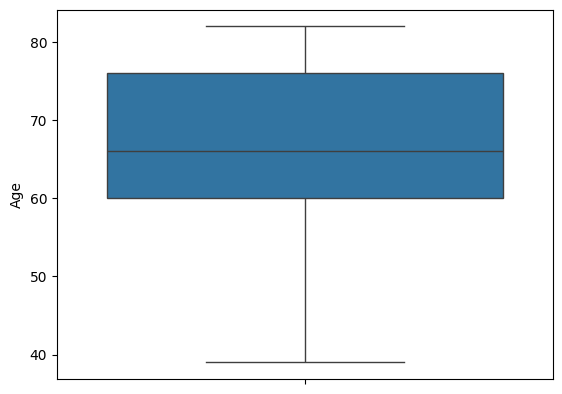

In [ ]:
import seaborn as sns
sns.boxplot(df_age)

In [ ]:
df_age.groupby(df_age).count()

,Age
Age,
39,1
52,1
55,1
57,1
58,1
59,3
60,2
63,1
64,5


In [ ]:
df_age.skew(), df_age.kurt()

(np.float64(-0.5334886996563224), np.float64(0.3893644294441909))

In [ ]:
# prompt: Gender by age

df_gender = df['Gender']
df_gender.isnull().sum()
df_gender.describe()
df_gender.groupby(df_gender).count()
df.groupby('Gender')['Age'].mean()
df.groupby('Gender')['Age'].median()
df.groupby('Gender')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,22.0,66.772727,10.295315,39.0,60.25,67.5,75.5,81.0
M,14.0,68.714286,9.227289,57.0,60.75,64.0,77.0,82.0


In [ ]:
df.columns

Index(['Name', 'Date', 'Age', 'Gender', 'Males', 'Females',
       'RE(Preop diagnosis)', 'LE(Preop diagnosis)', 'RE IOP', 'LE IOP',
       'RE Vision', 'LE Vision', 'Operating eye', 'RE R1', 'RE R2', 'RE A1',
       'LE R1', 'LE R2', 'LE A1', 'RE-AL', 'RE-ACD', 'RE LT', 'LE-AL',
       'LE-ACD', 'LE LT', 'IOLP'],
      dtype='object')